In [1]:
import zipfile
import os

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

os.listdir('data')

['synthetic_clinical_trial_data.csv']

In [2]:
import pandas as pd

df = pd.read_csv('data/synthetic_clinical_trial_data.csv')
print(df.head())
print(df.shape)

   Subject_ID  Site_ID  Age  Gender Enrollment_Date Treatment_Group  \
0           1       49   54    Male          1/1/22          Drug A   
1           2       37   44    Male          1/2/22         Placebo   
2           3        1   58    Male          1/3/22          Drug A   
3           4       25   48    Male          1/4/22          Drug B   
4           5       10   57  Female          1/5/22          Drug A   

   Adverse_Events  Dropout  Systolic_BP  Diastolic_BP  Cholesterol_Level  
0               0        0          117            74                229  
1               1        0          111            57                173  
2               0        1          122            89                220  
3               0        0          122            85                175  
4               2        0          105            90                185  
(1000, 11)


In [3]:
# Check missing data
print("Missing Values:")
print(df.isnull().sum())
print("\nData Summary:")
print(df.describe())

Missing Values:
Subject_ID           0
Site_ID              0
Age                  0
Gender               0
Enrollment_Date      0
Treatment_Group      0
Adverse_Events       0
Dropout              0
Systolic_BP          0
Diastolic_BP         0
Cholesterol_Level    0
dtype: int64

Data Summary:
        Subject_ID      Site_ID          Age  Adverse_Events      Dropout  \
count  1000.000000  1000.000000  1000.000000     1000.000000  1000.000000   
mean    500.500000    26.702000    50.447000        1.046000     0.161000   
std     288.819436    14.104614    15.383427        1.424048     0.367715   
min       1.000000     1.000000     6.000000        0.000000     0.000000   
25%     250.750000    15.000000    39.000000        0.000000     0.000000   
50%     500.500000    27.000000    51.000000        1.000000     0.000000   
75%     750.250000    38.250000    61.000000        2.000000     0.000000   
max    1000.000000    50.000000    98.000000       15.000000     1.000000   

       Sy

Adverse Events Distribution:
Adverse_Events
0     385
1     362
2     166
3      57
4      20
15      5
5       4
6       1
Name: count, dtype: int64


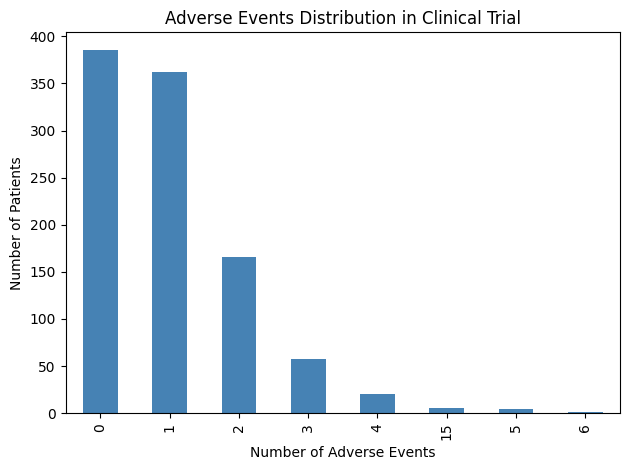

In [4]:
import matplotlib.pyplot as plt

# Adverse Events Analysis
ae_counts = df['Adverse_Events'].value_counts()
print("Adverse Events Distribution:")
print(ae_counts)

# Plot
ae_counts.plot(kind='bar', color='steelblue')
plt.title('Adverse Events Distribution in Clinical Trial')
plt.xlabel('Number of Adverse Events')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [6]:
# Dropout Analysis by Treatment
dropout = df.groupby('Treatment')['Dropout'].sum()
print("Dropout by Treatment:")
print(dropout)

dropout.plot(kind='bar', color='coral')
plt.title('Dropout Rate by Treatment Group')
plt.xlabel('Treatment')
plt.ylabel('Number of Dropouts')
plt.tight_layout()
plt.show()

KeyError: 'Treatment'

In [7]:
# Check column names first
print(df.columns.tolist())

['Subject_ID', 'Site_ID', 'Age', 'Gender', 'Enrollment_Date', 'Treatment_Group', 'Adverse_Events', 'Dropout', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Level']


In [8]:
dropout.plot(kind='bar', color='coral')
plt.title('Dropout Rate by Site')
plt.xlabel('Site ID')
plt.ylabel('Number of Dropouts')
plt.tight_layout()
plt.show()

NameError: name 'dropout' is not defined

Dropout by Site:
Site_ID
1      3
2      3
3      4
4      0
5      0
6      5
7      2
8      2
9      5
10     5
11     1
12     1
13     0
14     4
15     4
16     2
17     2
18     4
19     2
20     8
21     1
22     2
23     2
24     1
25     4
26     4
27     8
28     2
29     3
30     2
31     1
32     2
33     6
34    10
35     1
36     4
37     6
38     5
39     5
40     2
41     1
42     4
43     8
44     3
45     3
46     2
47     2
48     2
49     5
50     3
Name: Dropout, dtype: int64


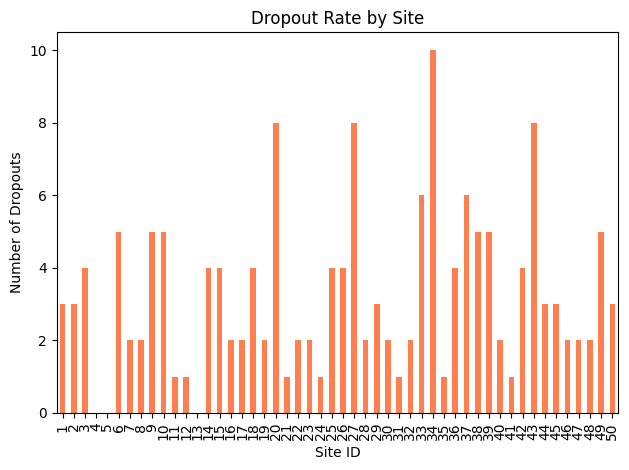

In [9]:
dropout = df.groupby('Site_ID')['Dropout'].sum()
print("Dropout by Site:")
print(dropout)

dropout.plot(kind='bar', color='coral')
plt.title('Dropout Rate by Site')
plt.xlabel('Site ID')
plt.ylabel('Number of Dropouts')
plt.tight_layout()
plt.show()

In [11]:
# SQL Analysis
import pandasql as psql

query = """
SELECT Site_ID,
COUNT(*) as Total_Patients,
SUM(Adverse_Events) as Total_AE,
SUM(Dropout) as Total_Dropouts
FROM df
GROUP BY Site_ID
ORDER BY Total_AE DESC
LIMIT 10
"""

result = psql.sqldf(query)
print("Top 10 Sites by Adverse Events:")
print(result)

ModuleNotFoundError: No module named 'pandasql'

In [12]:
!pip install pandasql

import pandasql as psql

query = """
SELECT Site_ID,
COUNT(*) as Total_Patients,
SUM(Adverse_Events) as Total_AE,
SUM(Dropout) as Total_Dropouts
FROM df
GROUP BY Site_ID
ORDER BY Total_AE DESC
LIMIT 10
"""

result = psql.sqldf(query)
print("Top 10 Sites by Adverse Events:")
print(result)

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=aadabbf39d0b762d8a0aab4beb46f2f7cae3e99f7746be410f3b10706550a6a1
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
Top 10 Sites by Adverse Events:
   Site_ID  Total_Patients  Total_AE  Total_Dropouts
0        9              21        40               5
1       43              27        39               8
2       27              23        36               8
3       20              29        36               8
4       10              30        36               5
5       13              12        34               0
6       37              27        31               6
7       28              28        30               2
8       42              26        28               4
9       21              19        28               1
